# 📊 Data Schema Documentation — nordic global weekly
## 1. Dataset Overview

### Grain
- ONE ROW = (country_name, week, show_title)
- This is the fact table — it captures weekly performance of shows per country.

### Business Purpose:
Supports KPI-driven analysis of content performance across Nordic markets, aligned with storytelling framework (performance, consistency, longevity).

----

## 2. Column Schema (Data Types + Roles)

| Column Name                  | Data Type (Power BI) | Type             | Description                     | Business Role                          |
| ---------------------------- | -------------------- | ---------------- | ------------------------------- | -------------------------------------- |
| `country_name`               | Text                 | Dimension        | Country (Sweden, Finland, etc.) | Market segmentation                    |
| `week`                       | Date                 | Dimension (Time) | Week start date                 | Time-series analysis                   |
| `category`                   | Text                 | Dimension        | Films / TV                      | Content segmentation                   |
| `weekly_rank`                | Whole Number         | Fact             | Rank (1–10)                     | Performance indicator (lower = better) |
| `show_title`                 | Text                 | Dimension        | Title name                      | Content entity                         |
| `cumulative_weeks_in_top_10` | Whole Number         | Fact             | Total weeks in Top 10           | Longevity metric                       |
| `year`                       | Whole Number         | Dimension        | Extracted year                  | Time slicing                           |
| `month`                      | Whole Number         | Dimension        | Extracted month (1–12)          | Aggregation                            |
| `Month Label`                | Text                 | Dimension        | “01 - January”                  | UX-friendly sorting                    |

----

## 3. Derived / Calculated Measures (DAX Layer)
### 🔹 3.1 Performance Score (Core KPI)
```
Performance Score = 
SUMX(
    'nordic global weekly',
    11 - 'nordic global weekly'[weekly_rank]
)
```

Logic:
```
Rank 1 → 10 points
Rank 10 → 1 point
```

- Converts ranking into a quantifiable performance metric
- Enables aggregation across time, country, category

### 🔹 3.2 Appearances (Consistency KPI)
`Appearances = COUNTROWS('nordic global weekly')`

- Measures how often a show appears
- Proxy for market visibility / consistency

### 🔹 3.3 Average Rank (Quality KPI)
`Average Rank = AVERAGE('nordic global weekly'[weekly_rank])`

- Measures average position
- Lower value = stronger performance

### 🔹 3.4 Longevity (Lifecycle KPI)
`Longevity = MAX('nordic global weekly'[cumulative_weeks_in_top_10])`

- Captures long-term success
- Identifies “sticky” content vs short-lived hits

### 🔹 3.5 Top 10 Flag
```
Top 10 Flag = 
IF('nordic global weekly'[weekly_rank] <= 10, 1, 0)
```

- Enables filtering
- Supports % calculations and KPI cards

----

## 4. Data Model Classification
🔴 Fact Columns
- weekly_rank
- cumulative_weeks_in_top_10

🔵 Dimensions
- country_name
- show_title
- category
- week, year, month, Month Label

🟢 Measures (Semantic Layer)
- Performance Score
- Appearances
- Average Rank
- Longevity
- Top 10 Flag


----

## 5. Analytical Capabilities Enabled

### 🎯 Performance DONE
“Top performing shows per country/month/year” 

### 📈 Trends DONE
“How performance evolves over time”

### 🔁 Consistency
“Which shows dominate repeatedly”

### ⏳ Lifecycle
“Which shows have long vs short impact”

## Load nordic_weekly dataset

In [36]:
import pandas as pd
import duckdb
from pathlib import Path   
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import seaborn as sns

In [7]:
DATA_PATH = Path("../../data/processed")

df = pd.read_csv(
    DATA_PATH / "nordic_global_weekly.csv",
    sep=";"
)

duckdb.register("nordic_weekly", df)

In [8]:
# Inside Duckdb filter nordics
nordic_df = duckdb.sql("""
SELECT *
FROM nordic_weekly
WHERE country_name IN ('Sweden','Norway','Denmark','Finland','Iceland')
""").df()

In [9]:
# Change year to datetime just in case
nordic_df["year"] = pd.to_datetime(nordic_df["week"]).dt.year

## Market Behavior Map
### “Which Nordic Countries Keep Netflix Shows Popular the Longest and Rank the Highest?”

### ✅ 1. Iceland leads in overall performance
- Iceland sits highest on the chart, meaning shows in Iceland tend to rank closer to #1 compared to other Nordic countries.
- Stronger content performance
- More dominant top shows

### ✅ 2. Norway balances strong rankings with consistency
- Norway appears near the top-right, showing that its shows both rank well and stay longer in the Top 10.
- Not just strong — also stable
- Reliable market performance

### ✅ 3. Finland shows weaker and less consistent performance
- Finland is positioned lower and more to the left, indicating that shows tend to rank lower and stay for fewer weeks.
- Less stable viewing patterns
- Content cycles faster

In [17]:
nordic_kpi_df = duckdb.sql("""
SELECT
    country_name,
    show_title,
    COUNT(*) AS appearances,
    SUM(11 - weekly_rank) AS performance_score,
    MAX(cumulative_weeks_in_top_10) AS longevity
FROM nordic_weekly
WHERE country_name IN ('Sweden','Norway','Denmark','Finland','Iceland')
GROUP BY country_name, show_title
""").df()

In [18]:
country_summary = nordic_kpi_df.groupby("country_name").agg(
    appearances=("appearances", "sum"),
    performance_score=("performance_score", "sum"),
    longevity=("longevity", "mean")
).reset_index()

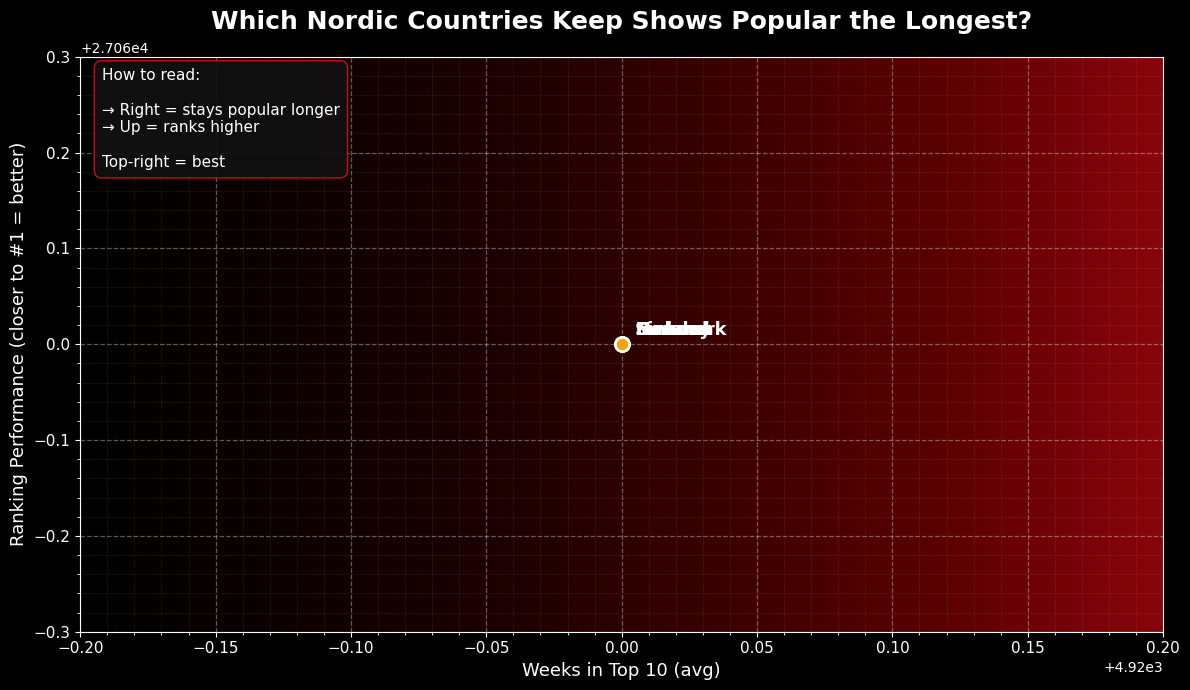

In [19]:
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(12, 7))

# --- 🎬 STRONGER Netflix gradient ---
gradient = np.linspace(0, 1, 512)
gradient = np.vstack((gradient, gradient))

cmap = LinearSegmentedColormap.from_list(
    "netflix_bg",
    [
        "#000000",  # pure black
        "#1a0000",
        "#330000",
        "#660000",
        "#990000",
        "#E50914"   # Netflix red
    ]
)

ax.imshow(
    gradient,
    aspect='auto',
    cmap=cmap,
    extent=[
        country_summary["appearances"].min() - 0.2,
        country_summary["appearances"].max() + 0.2,
        country_summary["performance_score"].min() - 0.3,
        country_summary["performance_score"].max() + 0.3
    ],
    alpha=0.6,   # 👈 KEY: lower so grid shows through
    zorder=0
)

# --- 🎨 Scatter colors ---
colors = {
    "Iceland": "#00FFB2",
    "Norway": "#00C2FF",
    "Denmark": "#FF3B3B",
    "Sweden": "#FFA500",
    "Finland": "#C77DFF"
}

# --- Scatter ---
for _, row in country_summary.iterrows():
    ax.scatter(
        row["appearances"],
        row["performance_score"],
        s=row["longevity"] * 40,
        color=colors.get(row["country_name"], "white"),
        edgecolor="white",
        linewidth=1.8,
        alpha=0.95,
        zorder=3
    )

# --- Labels ---
for _, row in country_summary.iterrows():
    ax.text(
        row["appearances"] + 0.005,
        row["performance_score"] + 0.01,
        row["country_name"],
        fontsize=13,
        color="white",
        weight="bold",
        zorder=4
    )

# --- Title ---
ax.set_title(
    "Which Nordic Countries Keep Shows Popular the Longest?",
    fontsize=18,
    color="white",
    weight="bold",
    pad=20
)

# --- Axis labels ---
ax.set_xlabel("Weeks in Top 10 (avg)", fontsize=13, color="white")
ax.set_ylabel("Ranking Performance (closer to #1 = better)", fontsize=13, color="white")

# --- Ticks ---
ax.tick_params(colors="white", labelsize=11)

# --- 🔥 STRONGER GRID (THIS IS THE FIX) ---
ax.grid(
    True,
    linestyle="--",
    linewidth=0.9,
    color="white",
    alpha=0.35   # 👈 more visible
)

# --- Optional: emphasize major grid lines ---
ax.minorticks_on()
ax.grid(which='minor', linestyle=":", linewidth=0.5, alpha=0.2)

# --- Explanation box ---
ax.text(
    0.02, 0.98,
    "How to read:\n\n"
    "→ Right = stays popular longer\n"
    "→ Up = ranks higher\n\n"
    "Top-right = best",
    transform=ax.transAxes,
    fontsize=11,
    color="white",
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="#111111",
        edgecolor="#E50914",
        alpha=0.9
    )
)

plt.tight_layout()
plt.show()

## Which shows stayed popular the longest, and in which countries?

### ✅ 1. A small number of shows dominate across multiple countries
A few shows appear with darker colors across several Nordic countries, meaning they stayed in the Top 10 for many weeks and had broad regional popularity.

### ✅ 2. Some shows are highly localized
Certain shows are dark in one country but much lighter in others, indicating they were popular in specific markets but did not spread across the region.

### ✅ 3. Not all top shows are consistent across countries
Even among the top-ranked shows, performance varies significantly by country, showing that popularity is not uniform across the Nordic region.

### ✅ 4. Longevity matters more than peak ranking
The heatmap highlights shows that stayed in the Top 10 for many weeks, emphasizing consistent popularity rather than short-term spikes. Focus is on sustained success, not just viral moments

In [27]:
heatmap_df = duckdb.sql("""
SELECT
    show_title,
    country_name,
    MAX(cumulative_weeks_in_top_10) AS total_weeks
FROM nordic_weekly
GROUP BY show_title, country_name
""").df()

In [39]:
duckdb.sql("""
SELECT 
    MIN(week) AS start_date,
    MAX(week) AS end_date
FROM nordic_weekly
""").df()

,start_date,end_date
0,2021-07-04 00:00:00,2026-03-15 00:00:00


In [30]:
pivot_top = heatmap_df.pivot(
    index="show_title",
    columns="country_name",
    values="total_weeks"
).fillna(0)

In [33]:
top_shows = heatmap_df.groupby("show_title")["total_weeks"].sum().nlargest(15).index
pivot_top["total"] = pivot_top.sum(axis=1)
pivot_top = pivot_top.sort_values("total", ascending=False).drop(columns="total")

# Optional: top 10 only
pivot_top = pivot_top.head(10)


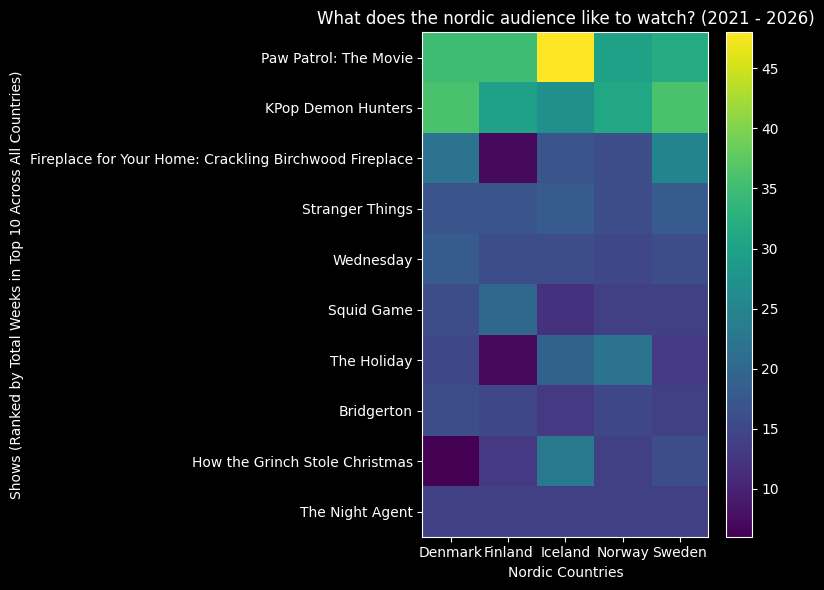

In [34]:
plt.figure(figsize=(8,6))
plt.imshow(pivot_top, aspect='auto')

plt.xticks(range(len(pivot_top.columns)), pivot_top.columns)
plt.yticks(range(len(pivot_top.index)), pivot_top.index)

plt.xlabel("Nordic Countries")
plt.ylabel("Shows (Ranked by Total Weeks in Top 10 Across All Countries)")

plt.title("What does the nordic audience like to watch? (2021 - 2026)")

plt.colorbar()

plt.tight_layout()
plt.show()

### 2026 Heatmap for Popular Shows Nordics

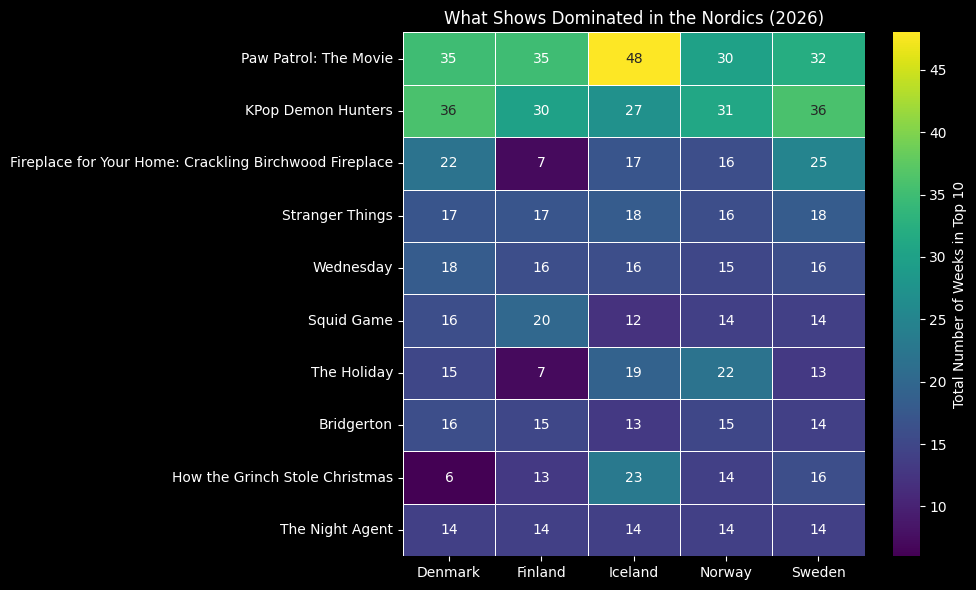

In [50]:
# Total Weeks Each Show Appeared in Top 10 Across Nordic Countries
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_top,
    cmap="viridis",
    annot=True,          
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={'label': 'Total Number of Weeks in Top 10'}
)

plt.title("What Shows Dominated in the Nordics (2026)")
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()

plt.show()